## Bank Loan Predictive Analytics 
### Exploratory Data Analysis & Feature Engineering

## 1. Environment Setup & Core Library Imports

In [1]:
# Standard data manipulation tools
import pandas as pd
import numpy as np

# Data visualization frameworks
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean aesthetic layout style for all upcoming visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Data Acquisition
Loading the banking customer profiles raw dataset.

In [2]:
# Load data from source file. Let's name our initial dataframe variable carefully.
data = pd.read_csv("Bank_Personal_Loan_Modelling.csv")

# Display structural overview of the dataset
data

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


## 3. Preliminary Structural Diagnostics
Inspecting structural orientation, observations, bounds, data types, and missing indices.

In [3]:
# Preview the top 5 records to understand target features and value alignments
data.head(5)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


### Previewing Bottom Records

In [4]:
# Check trailing 5 rows to ensure no faulty formatting or missing tail elements exist
data.tail(5)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


### Matrix Dimensions

In [5]:
# Check dimensions of our dataset matrix format: (Total Rows, Total Columns)
print(f"Dataset Structure Dimensions: {data.shape}")

Dataset Structure Dimensions: (5000, 14)


### Data Completeness Analysis

In [6]:
# Check across features to detect missing entries or NaN inputs requiring imputation
data.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

### Available Attributes

In [7]:
# Retrieve exact system names of all internal dataset variables
data.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

### Feature Data Types

In [8]:
# Verify pandas-assigned schema types to ensure continuous vs. discrete elements align
data.dtypes

ID                      int64
Age                     int64
Experience              int64
Income                  int64
ZIP Code                int64
Family                  int64
CCAvg                 float64
Education               int64
Mortgage                int64
Personal Loan           int64
Securities Account      int64
CD Account              int64
Online                  int64
CreditCard              int64
dtype: object

## 4. Key Demographic Distributions
Isolating primary customer indicators to evaluate scale, central trends, and boundaries.

In [9]:
# Target descriptive statistics for primary metrics to identify structural anomalies 
# Note: Let's keep an eye out for any weird inputs (e.g., negative experience metrics)
summary_stats = data[['Age', 'Experience', 'Income', 'Family', 'Education']].describe()
summary_stats

,Age,Experience,Income,Family,Education
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,45.338400,20.104600,73.774200,2.396400,1.881000
std,11.463166,11.467954,46.033729,1.147663,0.839869
min,23.000000,-3.000000,8.000000,1.000000,1.000000
25%,35.000000,10.000000,39.000000,1.000000,1.000000
50%,45.000000,20.000000,64.000000,2.000000,2.000000
75%,55.000000,30.000000,98.000000,3.000000,3.000000
max,67.000000,43.000000,224.000000,4.000000,3.000000


## 5. Visualizing Feature Spread & Outliers

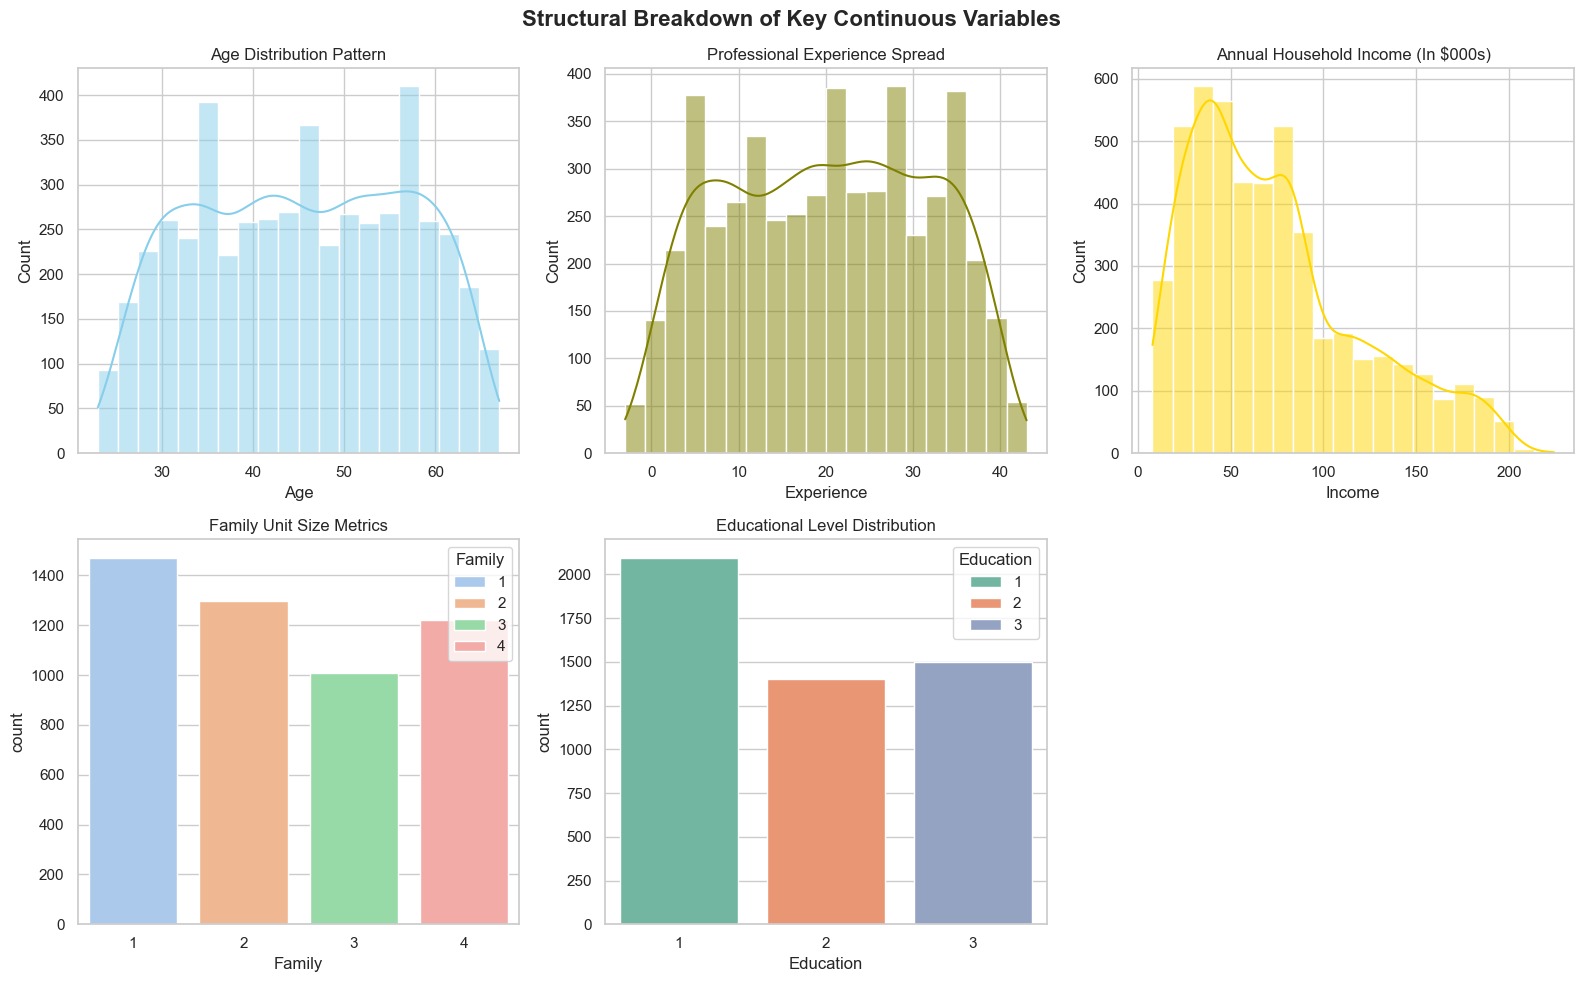

In [10]:
# Establish grid frame variables for unified subplots evaluation
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Structural Breakdown of Key Continuous Variables', fontsize=16, fontweight='bold')

# Subplot [0,0]: Age distribution tracking
sns.histplot(data['Age'], bins=20, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Age Distribution Pattern')

# Subplot [0,1]: Experience variation profiles
sns.histplot(data['Experience'], bins=20, kde=True, ax=axes[0, 1], color='olive')
axes[0, 1].set_title('Professional Experience Spread')

# Subplot [0,2]: Base annual salary metric profile 
sns.histplot(data['Income'], bins=20, kde=True, ax=axes[0, 2], color='gold')
axes[0, 2].set_title('Annual Household Income (In $000s)')

# Subplot [1,0]: Structural size of household units
sns.countplot(x='Family', hue='Family', data=data, ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Family Unit Size Metrics')

# Subplot [1,1]: Education level segmentation indexes
sns.countplot(x='Education', hue='Education', data=data, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Educational Level Distribution')

# Clear empty subplot [1,2] placeholder frame safely
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

## 6. Target Variable Inspection & Unique Value Analysis

In [11]:
# Review distinct points across feature values to capture scaling
print("Distinct Income brackets found:", data['Income'].unique())

# Evaluate distributions for portfolio accounts
print("\nSecurities Account balance profile:")
print(data['Securities Account'].value_counts())

print("\nCertificate of Deposit (CD) Account split:")
print(data['CD Account'].value_counts())

Distinct Income brackets found: [ 49  34  11 100  45  29  72  22  81 180 105 114  40 112 130 193  21  25
  63  62  43 152  83 158  48 119  35  41  18  50 121  71 141  80  84  60
 132 104  52 194   8 131 190  44 139  93 188  39 125  32  20 115  69  85
 135  12 133  19  82 109  42  78  51 113 118  64 161  94  15  74  30  38
   9  92  61  73  70 149  98 128  31  58  54 124 163  24  79 134  23  13
 138 171 168  65  10 148 159 169 144 165  59  68  91 172  55 155  53  89
  28  75 170 120  99 111  33 129 122 150 195 110 101 191 140 153 173 174
  90 179 145 200 183 182  88 160 205 164  14 175 103 108 185 204 154 102
 192 202 162 142  95 184 181 143 123 178 198 201 203 189 151 199 224 218]

Securities Account balance profile:
Securities Account
0    4478
1     522
Name: count, dtype: int64

Certificate of Deposit (CD) Account split:
CD Account
0    4698
1     302
Name: count, dtype: int64


## 7. Advanced Feature Engineering
Combining multi-source indicators to isolate customer engagement clusters.

In [12]:
def security(row):
    """
    Maps investment and fixed-term savings interaction cross-sections 
    to define high-value relationship groups.
    """
    if (row['Securities Account'] == 1) & (row['CD Account'] == 1):
        return "Both Security and Deposit Account"
    elif (row['Securities Account'] == 0) & (row['CD Account'] == 0):
        return "No Account"
    elif (row['Securities Account'] == 1) & (row['CD Account'] == 0):
        return "Only Security Account"
    elif (row['Securities Account'] == 0) & (row['CD Account'] == 1):
        return "Only Deposit Account"

In [13]:
# Execute mapping iteratively on data row structures
data['Account_Holder_Category'] = data.apply(security, axis=1)
data[['Securities Account', 'CD Account', 'Account_Holder_Category']].head(5)

,Securities Account,CD Account,Account_Holder_Category
0,1,0,Only Security Account
1,1,0,Only Security Account
2,0,0,No Account
3,0,0,No Account
4,0,0,No Account


## 8. Financial Correlation & Interaction Patterns

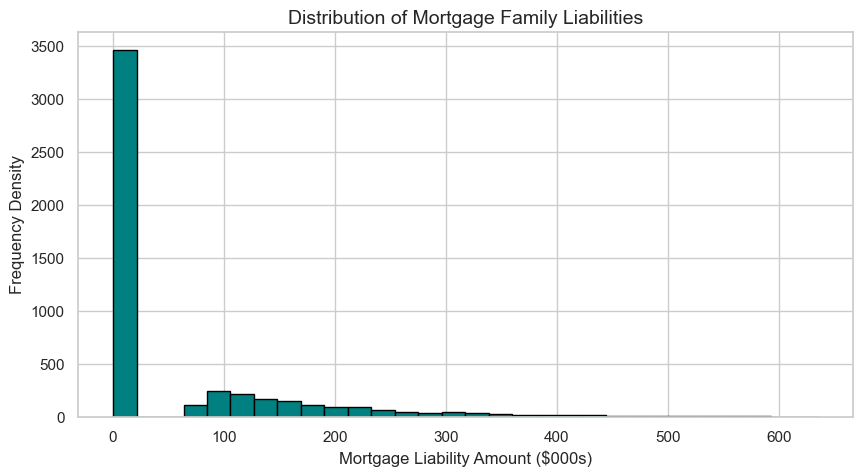

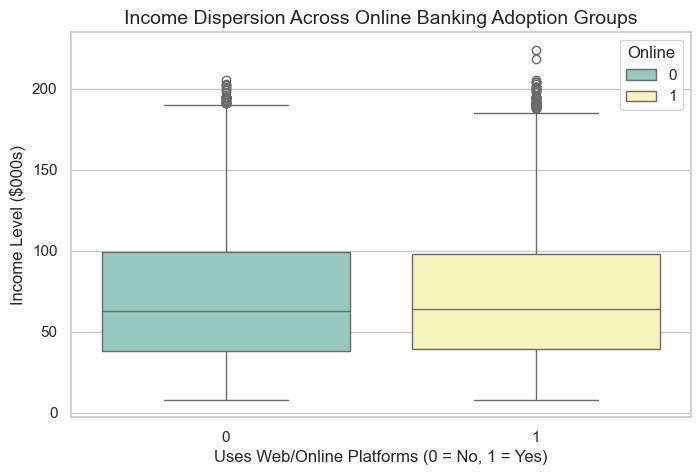

In [14]:
# Create structural distribution visual for Mortgage values across population segments
plt.figure(figsize=(10, 5))
data['Mortgage'].hist(bins=30, color='teal', edgecolor='black')
plt.title('Distribution of Mortgage Family Liabilities', fontsize=14)
plt.xlabel('Mortgage Liability Amount ($000s)')
plt.ylabel('Frequency Density')
plt.show()

# Check interaction variance between Digital Engagement platforms and Customer Income
plt.figure(figsize=(8, 5))
sns.boxplot(x='Online', y='Income', hue='Online', data=data, palette='Set3')
plt.title('Income Dispersion Across Online Banking Adoption Groups', fontsize=14)
plt.xlabel('Uses Web/Online Platforms (0 = No, 1 = Yes)')
plt.ylabel('Income Level ($000s)')
plt.show()

### Multivariant Correlation Tracking Metrics

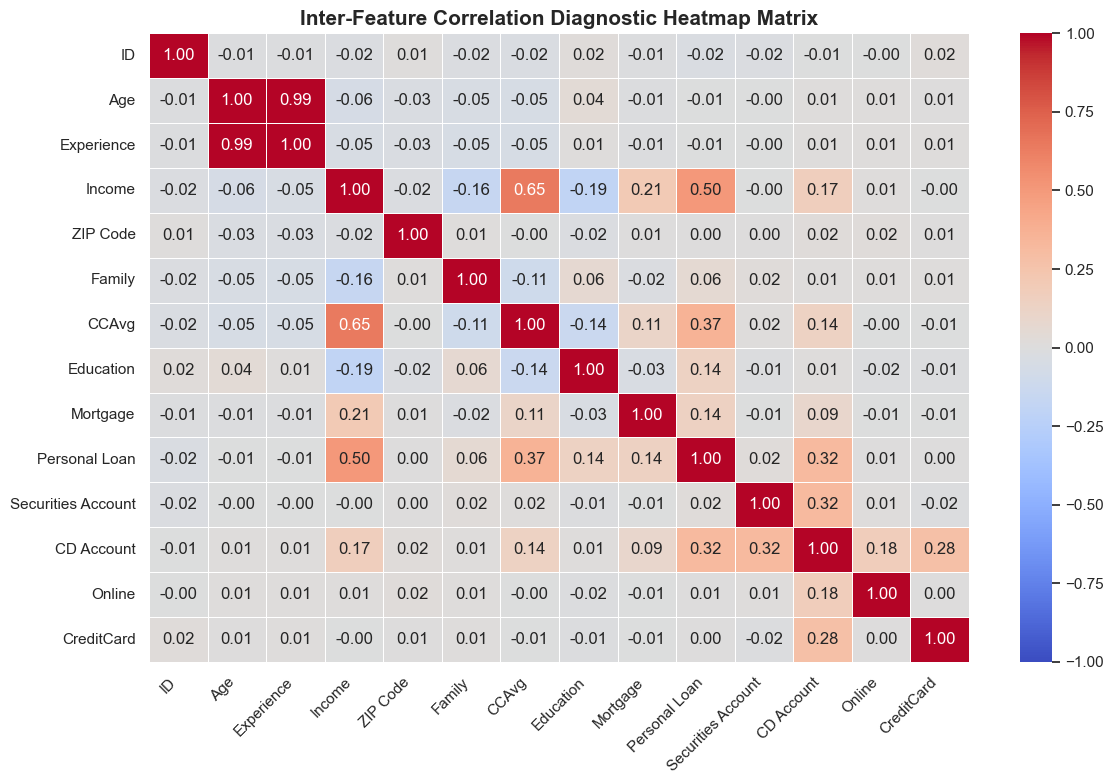

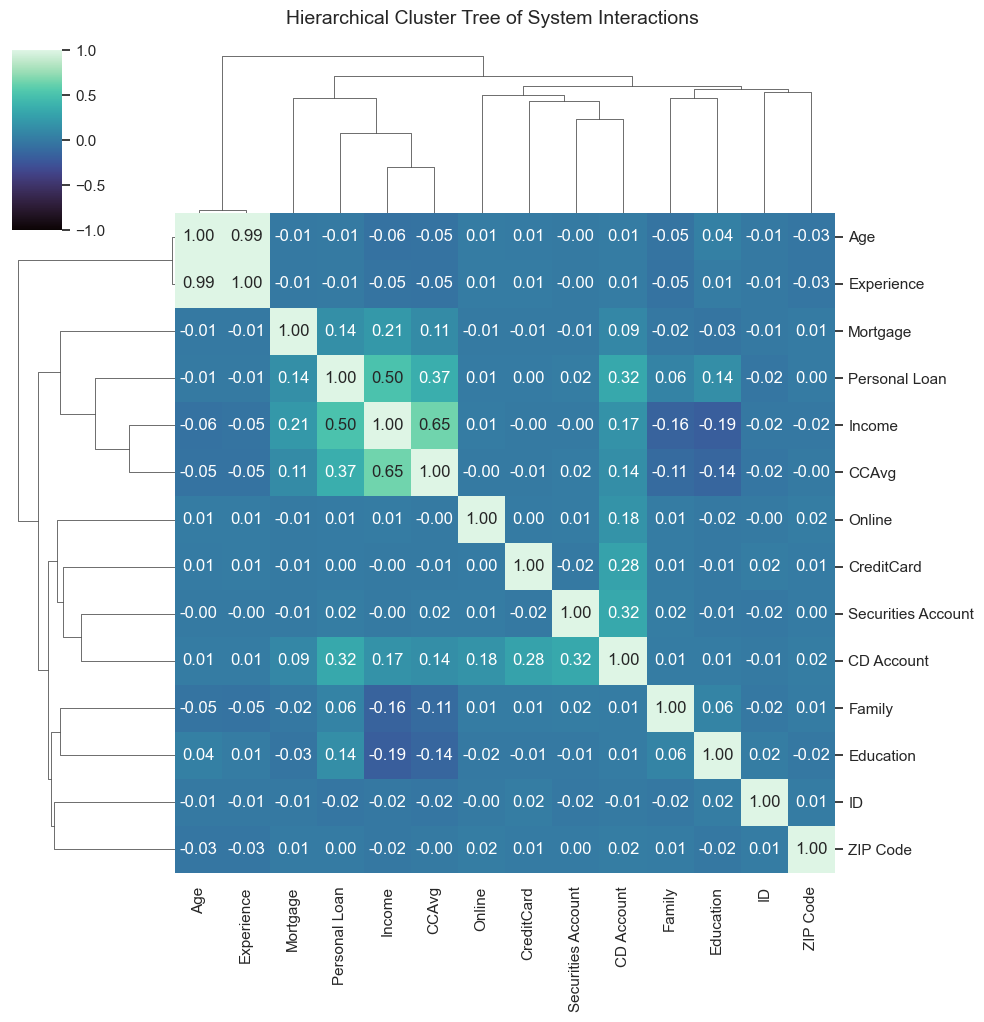

In [15]:
# Compute standard Pearson correlation coefficient patterns 
# We drop our descriptive engineered string feature to keep calculations numeric
correlations = data.drop(columns=['Account_Holder_Category']).corr()

def format_heatmap(corr_matrix):
    """
    Generates a calibrated linear divergence correlation display map.
    """
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)

# Structural Correlation Matrix Plotting
plt.figure(figsize=(12, 8))
format_heatmap(correlations)
plt.title('Inter-Feature Correlation Diagnostic Heatmap Matrix', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Generate systematic Clustering Relationships Tree Matrix
sns.clustermap(correlations, annot=True, fmt=".2f", cmap='mako', vmin=-1, vmax=1)
plt.suptitle('Hierarchical Cluster Tree of System Interactions', y=1.02, fontsize=14)
plt.show()